In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/TCGA Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((496, 19277), (124, 19277), (496,), (124,))


Calculating SHAP values...
SHAP values shape: (124, 100, 5)
Selected features: 100

=== Overall Top 10 Features ===
    Feature  MeanAbsSHAP_MaxAcrossSubtypes
7    AXDND1                       0.023027
46   OSGIN2                       0.019442
71  MIR1178                       0.018933
82   SEPT12                       0.018352
8   PIP5K1A                       0.017109
51    LRRC6                       0.016843
80   ABCC11                       0.016050
39   ZNF366                       0.015383
96  BPIFA4P                       0.014713
98    PREX1                       0.013465


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_19016\3030200669.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


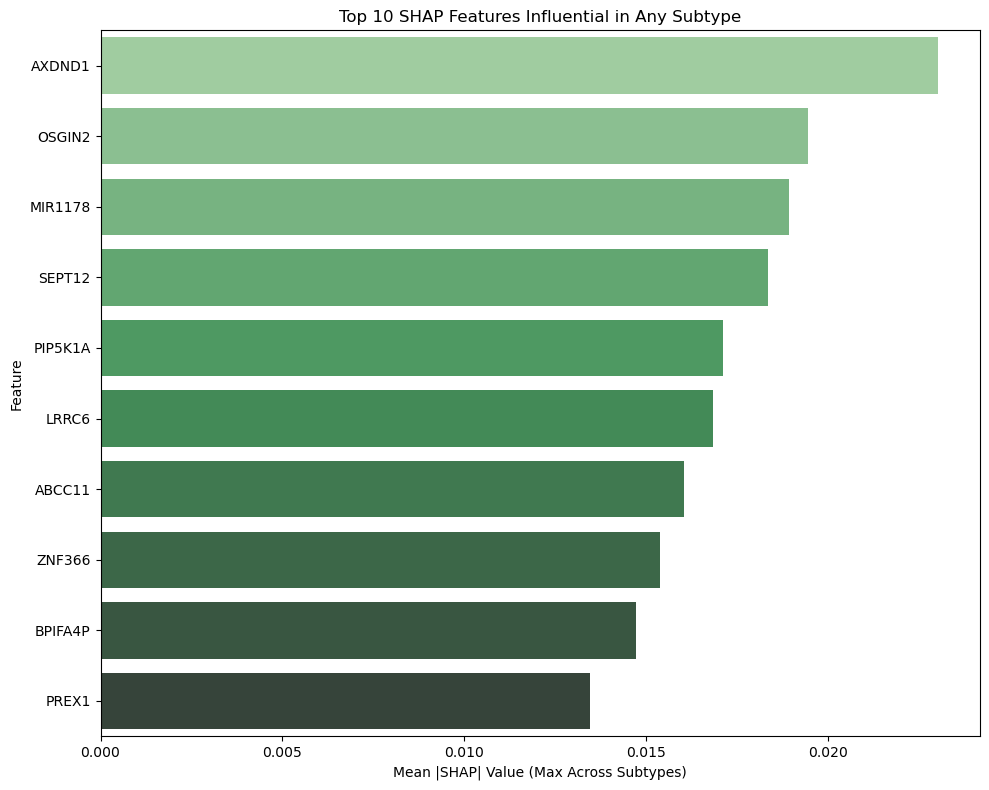

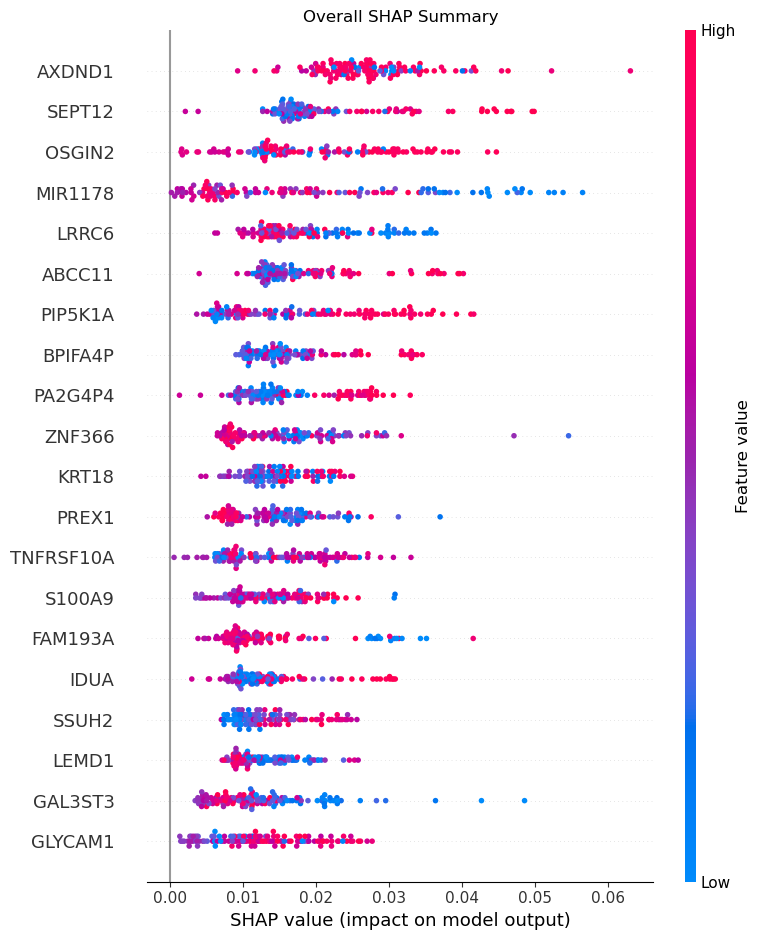


Subtype 1: Basal
      Feature  MeanAbsSHAP
82     SEPT12     0.018352
7      AXDND1     0.017966
80     ABCC11     0.016050
26       IDUA     0.012069
5     MIR135B     0.011531
19    PA2G4P4     0.010951
27    SLC26A1     0.010157
49  LOC727677     0.009822
81  LOC440335     0.009177
59      RGS10     0.008877


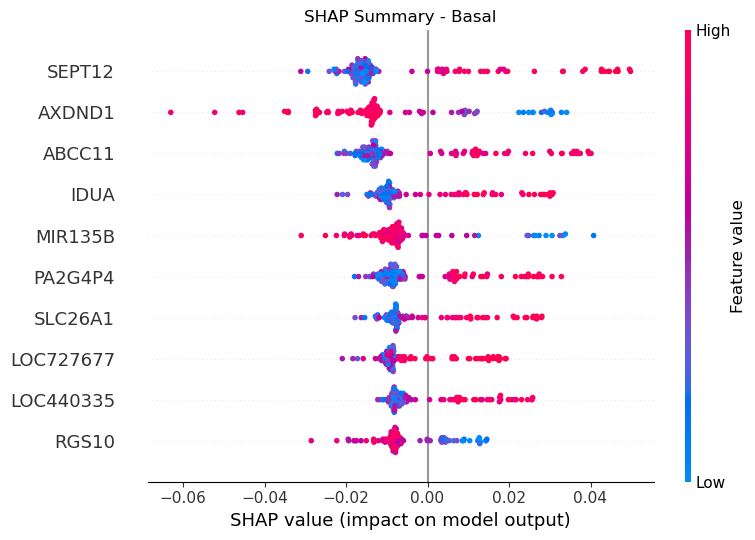

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_19016\3030200669.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


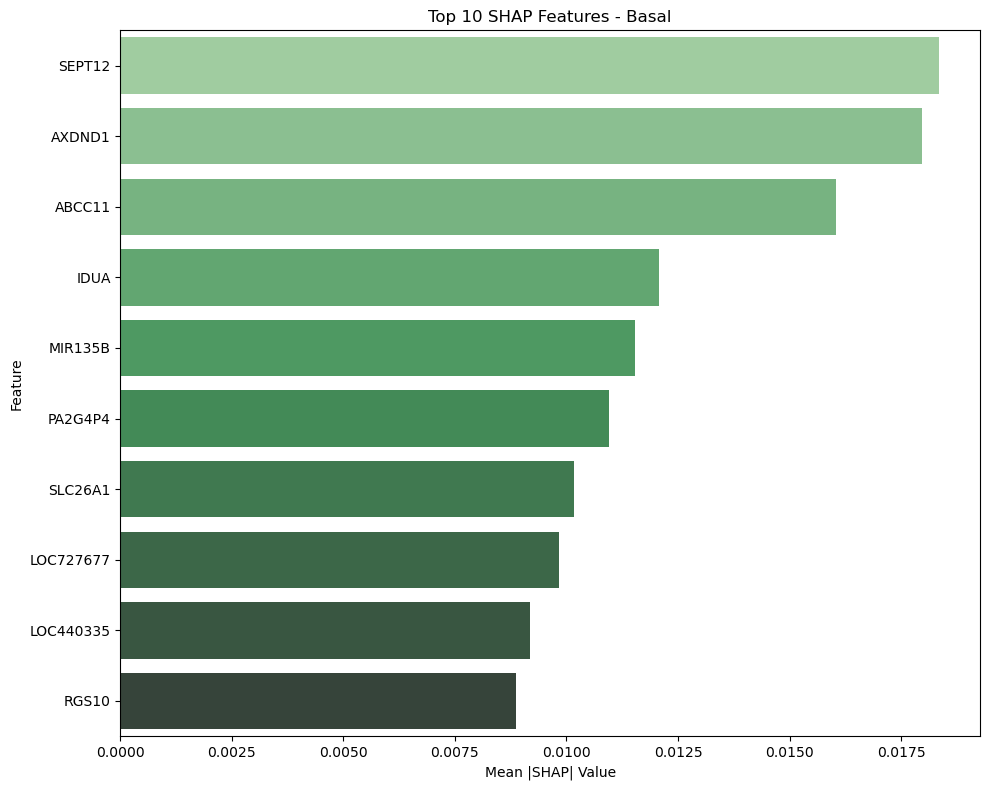


Subtype 2: Her2
      Feature  MeanAbsSHAP
7      AXDND1     0.017222
39     ZNF366     0.015383
98      PREX1     0.013465
65    GLYCAM1     0.012248
46     OSGIN2     0.011910
51      LRRC6     0.010742
3       LEMD1     0.010596
19    PA2G4P4     0.010417
48  TNFRSF10A     0.010058
8     PIP5K1A     0.009757


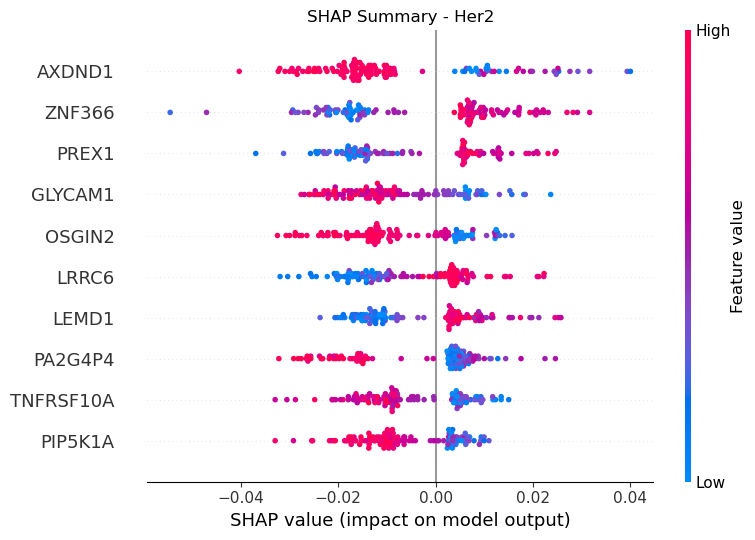

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_19016\3030200669.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


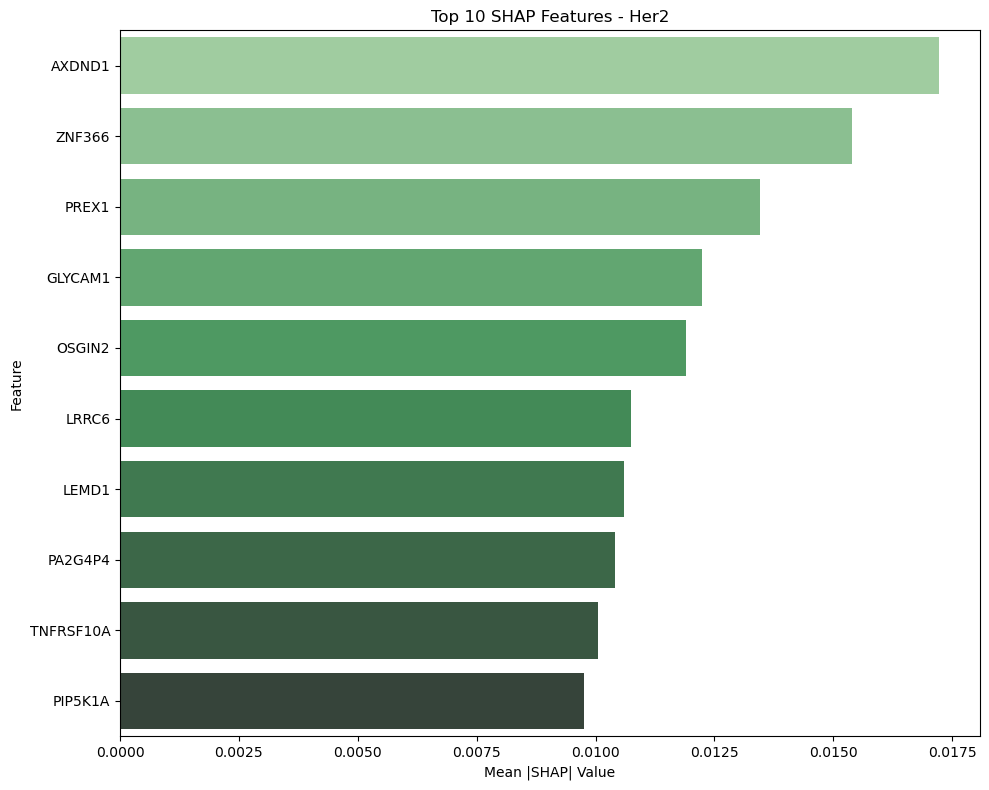


Subtype 3: LumA
         Feature  MeanAbsSHAP
7         AXDND1     0.023027
46        OSGIN2     0.019442
71       MIR1178     0.018933
8        PIP5K1A     0.017109
48     TNFRSF10A     0.013422
6         S100A9     0.012352
68          TMPO     0.012103
82        SEPT12     0.011489
67  LOC100128191     0.011257
98         PREX1     0.011025


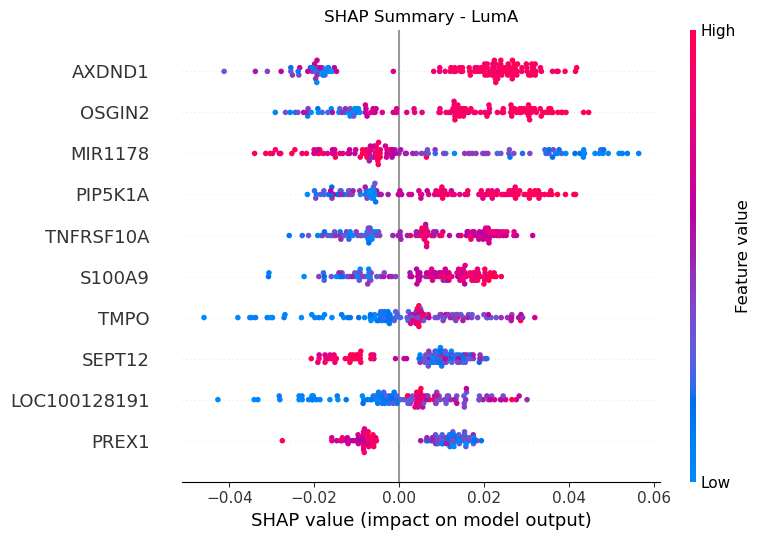

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_19016\3030200669.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


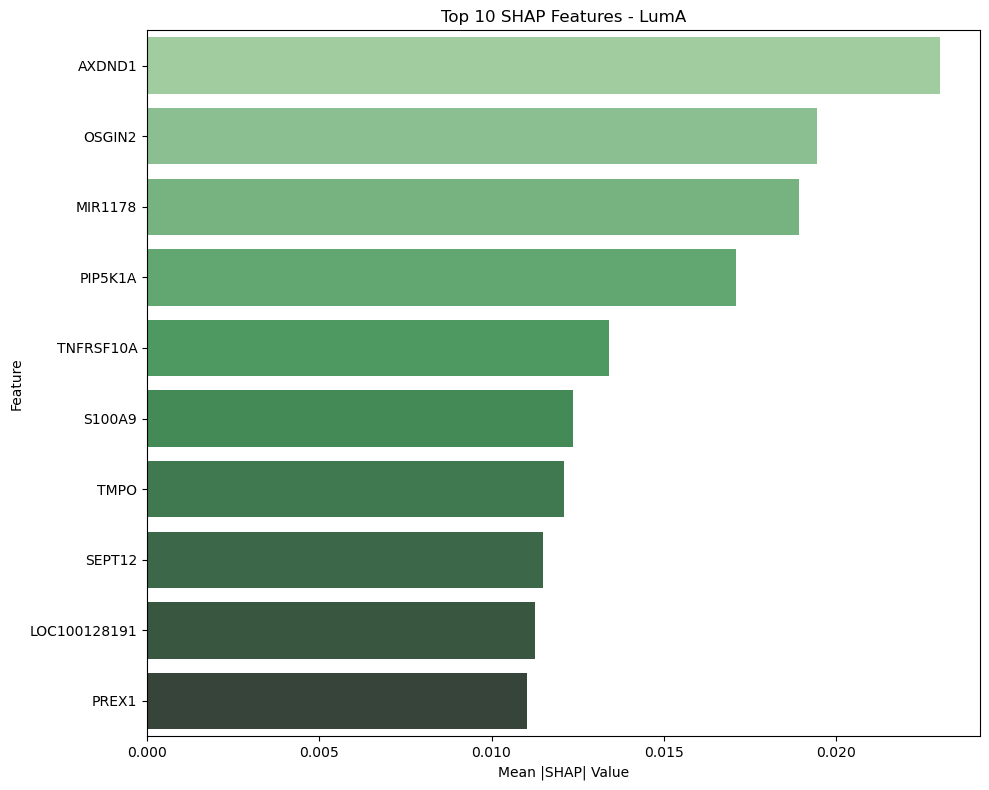


Subtype 4: LumB
         Feature  MeanAbsSHAP
51         LRRC6     0.016843
71       MIR1178     0.015552
82        SEPT12     0.011296
68          TMPO     0.011063
67  LOC100128191     0.010512
39        ZNF366     0.010263
3          LEMD1     0.009563
43        AHCYL2     0.008875
98         PREX1     0.008413
80        ABCC11     0.008316


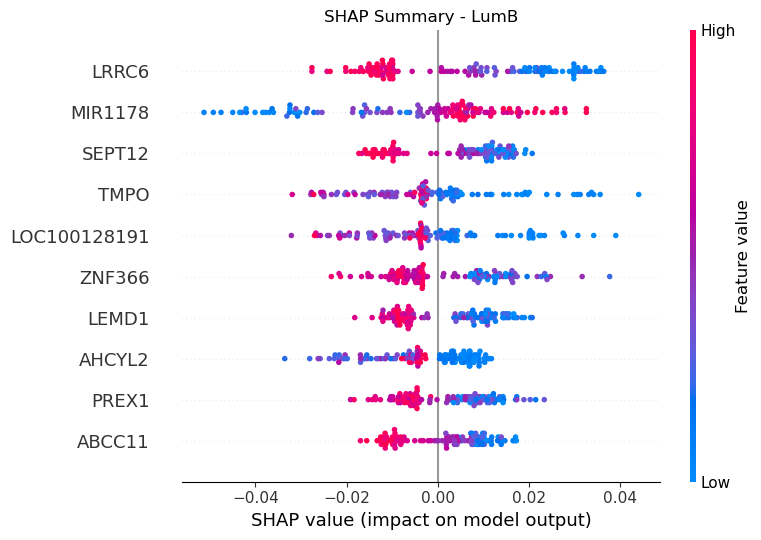

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_19016\3030200669.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


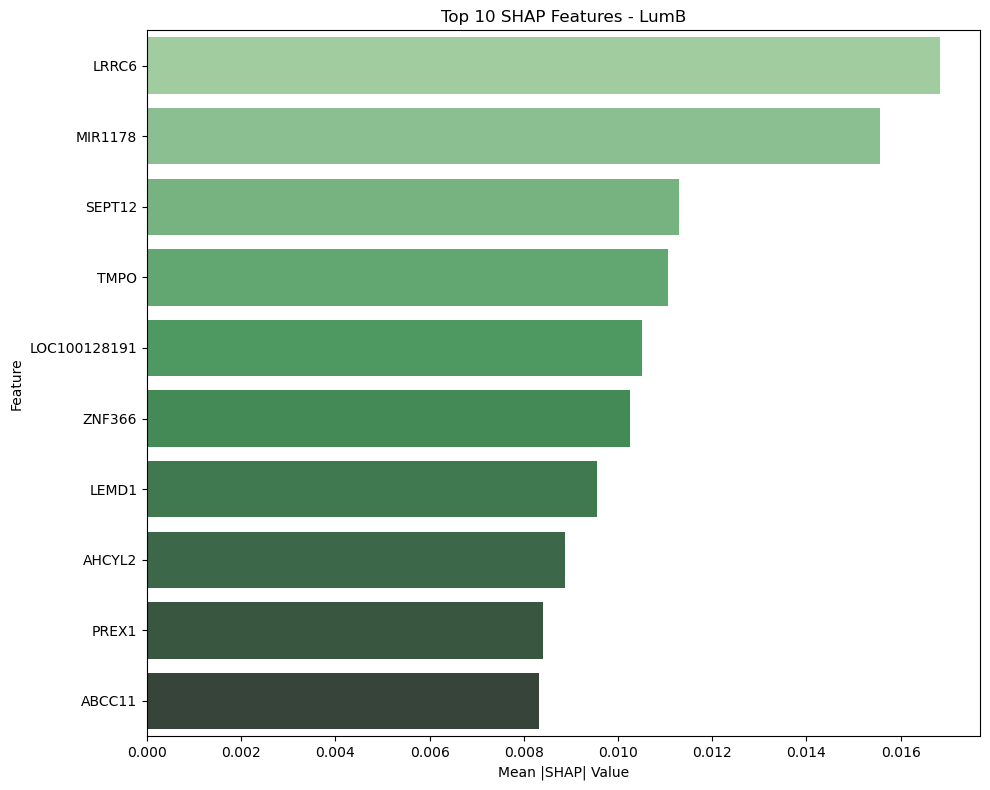


Subtype 5: Normal
    Feature  MeanAbsSHAP
96  BPIFA4P     0.014713
28  FAM193A     0.011906
22   POPDC2     0.011900
82   SEPT12     0.011228
16    SSUH2     0.011146
19  PA2G4P4     0.011124
45  CYP3A43     0.010343
61  GAL3ST3     0.010161
80   ABCC11     0.010074
70    KRT18     0.009178


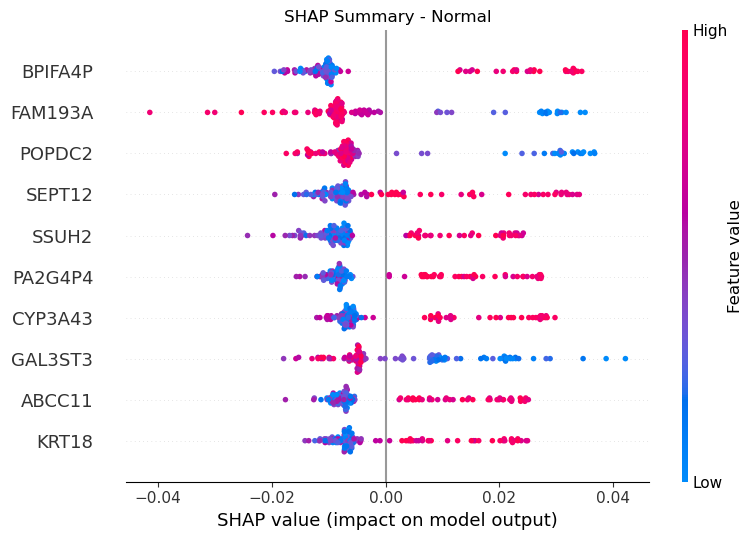

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_19016\3030200669.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


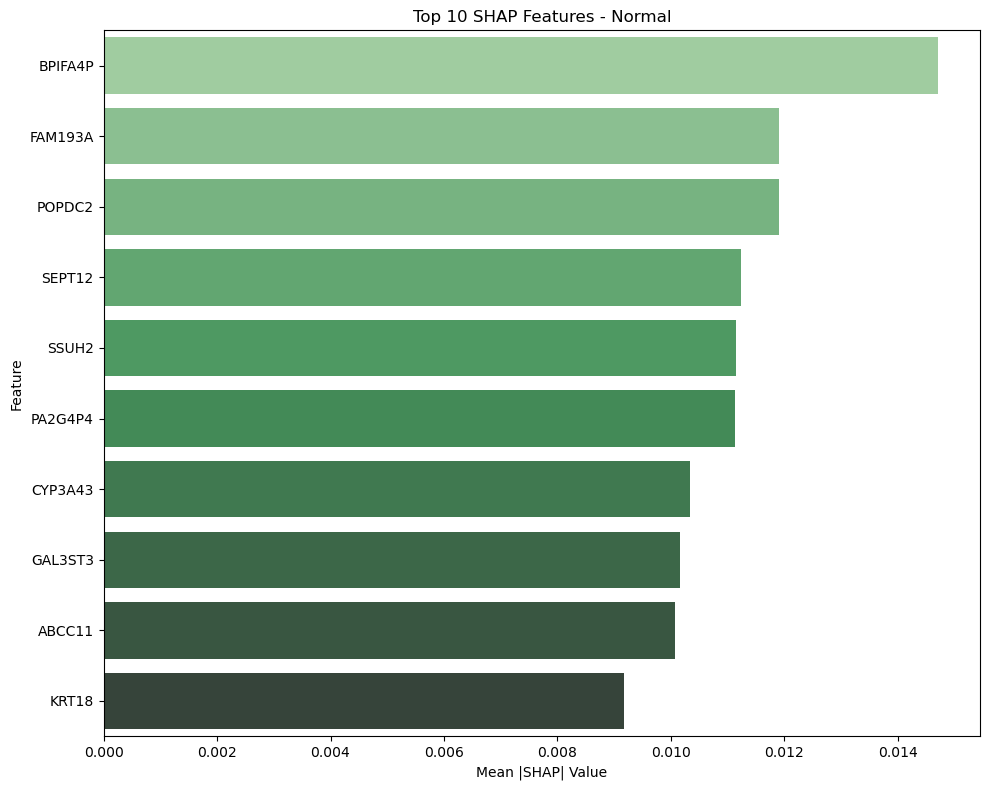


SHAP analysis complete — both overall and per-subtype results generated.


In [ ]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_TCGA_SMOTE_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

X_test_selected = X_test.values[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")